# Gåshamna Whale Bone Topographic & Landscape Analysis

This notebook provides a comprehensive topographic and landscape analysis of the whale bone remains at Gåshamna, Svalbard. By combining archaeological spatial data with a high-resolution Digital Elevation Model (DEM), we analyze the relationship between whale bone remains and geographic features.

---

## Table of Contents
1. **Section 1: Elevation and Skeletal Elements** - Analyzes the height distribution of different spatial clusters and individual bone types (elements).
2. **Section 2: Bone Size vs. Elevation (Logistics)** - Correlates the size of the bones with their elevation to identify potential transport/logistical patterns.
3. **Section 3: Surface Stability & Slope Gradient** - Calculates slope gradients from the DEM and evaluates the ground stability of each cluster area.


## Section 1: Topographic Positioning (Elevation & Skeletal Elements)

### Purpose
To extract elevation values (height above sea level) for each whale bone from the DEM raster and analyze the vertical distribution of spatial clusters and specific bone elements.

### Workflow & Functions
1. **Data Loading**: Loads the spatial points shapefile/geopackage (`Points` layer).
2. **Filtering**: Filters out the DBSCAN noise cluster (`cluster_id == -1`) to focus on the defined whale bone clusters.
3. **Elevation Extraction**: Opens the DEM raster (`Gashamda_DEM_250822.tif`), aligns the CRS if necessary, and samples elevation values at the point coordinates using `rasterio.sample`.
4. **Visualizations**:
   - **Plot A (Boxplot)**: Represents the distribution of heights above sea level for each cluster to identify which areas are situated on higher terraces versus closer to the shore.
   - **Plot B (Stripplot)**: Shows the heights at which different skeletal elements (e.g., ribs, vertebrae, jawbones) are distributed to see if specific bone types were transported to higher levels.
5. **Statistical Summary**: Outputs numerical statistics (mean, standard deviation, min, max) for elevation per cluster.

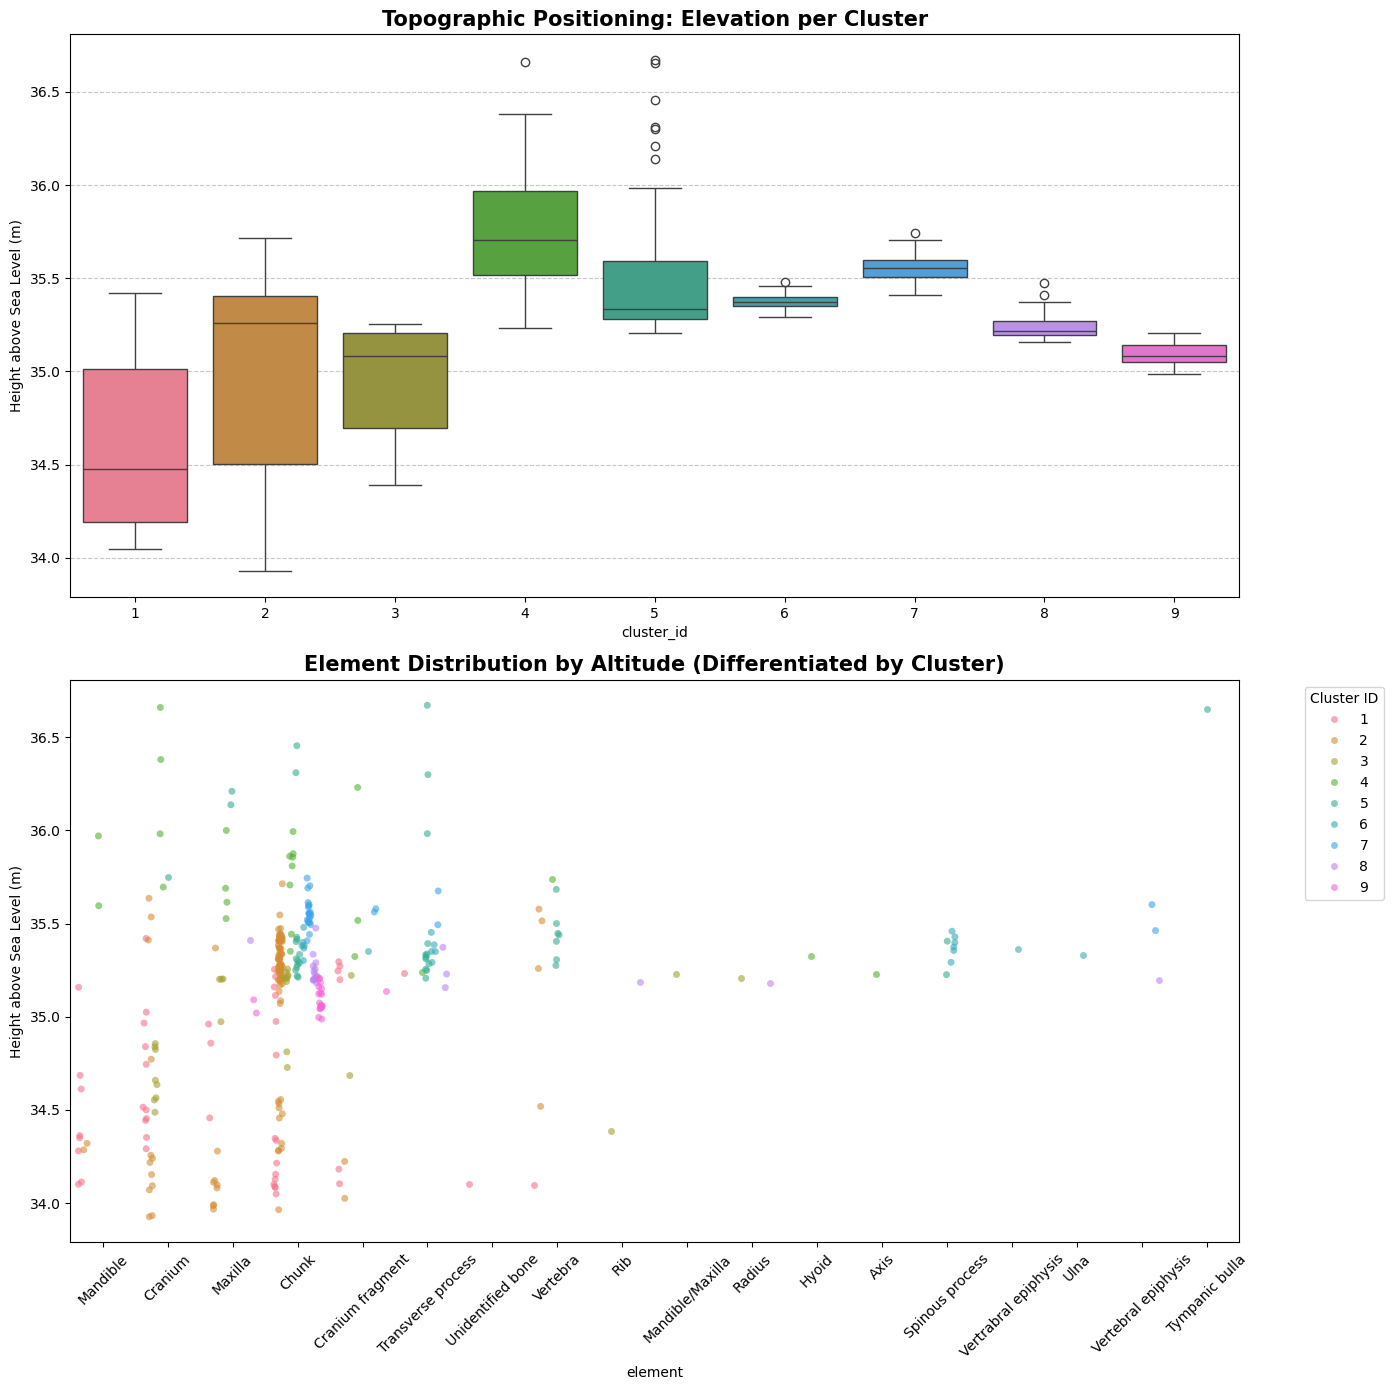

--- TOPOGRAPHIC SUMMARY (in meters) ---
                 mean   std        min        max
cluster_id                                       
1           34.610001  0.44  34.049999  35.419998
2           35.000000  0.53  33.930000  35.709999
3           34.950001  0.29  34.389999  35.259998
4           35.750000  0.35  35.230000  36.660000
5           35.549999  0.43  35.209999  36.669998
6           35.380001  0.05  35.290001  35.480000
7           35.560001  0.08  35.410000  35.740002
8           35.250000  0.08  35.160000  35.480000
9           35.099998  0.07  34.990002  35.209999


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# =================================================================
# 1. SETTINGS
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Clusters_Final.gpkg')

# =================================================================
# 2. LOAD DATA
# =================================================================
whales = gpd.read_file(points_gpkg, layer='Points')
whales_clustered = whales[whales['cluster_id'] != -1].copy()

# =================================================================
# 3. EXTRACT ELEVATION (Subprocess call to avoid DLL conflicts on Windows)
# =================================================================
import subprocess
import sys

base_path_esc = base_path.replace('\\', '\\\\')

subprocess.run([sys.executable, "-c", f"""
import geopandas as gpd
import rasterio
import numpy as np
import os

base_path = r"{base_path_esc}"
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Clusters_Final.gpkg')

whales = gpd.read_file(points_gpkg, layer='Points')
whales_clustered = whales[whales['cluster_id'] != -1].copy()

with rasterio.open(dem_path) as src:
    if whales_clustered.crs != src.crs:
        whales_clustered = whales_clustered.to_crs(src.crs)
    coord_list = np.column_stack((whales_clustered.geometry.x, whales_clustered.geometry.y))
    whales_clustered['elevation'] = [val[0] for val in src.sample(coord_list)]

whales_clustered.to_pickle('temp_elevation.pkl')
"""])

whales_clustered = pd.read_pickle('temp_elevation.pkl')
if os.path.exists('temp_elevation.pkl'):
    os.remove('temp_elevation.pkl')

# =================================================================
# 4. ENHANCED VISUALIZATION
# =================================================================
num_clusters = len(whales_clustered['cluster_id'].unique())
cluster_palette = sns.color_palette("husl", num_clusters)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Plot A: Elevation per Cluster (Boxplot)
sns.boxplot(
    data=whales_clustered, 
    x='cluster_id', 
    y='elevation', 
    hue='cluster_id', 
    ax=ax1, 
    palette=cluster_palette, 
    legend=False
)
ax1.set_title('Topographic Positioning: Elevation per Cluster', fontsize=15, fontweight='bold')
ax1.set_ylabel('Height above Sea Level (m)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot B: Skeletal Elements vs Elevation (Stripplot)
sns.stripplot(
    data=whales_clustered, 
    x='element', 
    y='elevation', 
    hue='cluster_id', 
    ax=ax2, 
    palette=cluster_palette,
    dodge=True,
    alpha=0.6, 
    size=5,
    jitter=0.3
)
plt.xticks(rotation=45)
ax2.set_title('Element Distribution by Altitude (Differentiated by Cluster)', fontsize=15, fontweight='bold')
ax2.set_ylabel('Height above Sea Level (m)')
ax2.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'Whale_Topography_Analysis_HighRes.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print-Out für die numerische Relevanzprüfung
print("--- TOPOGRAPHIC SUMMARY (in meters) ---")
print(whales_clustered.groupby('cluster_id')['elevation'].agg(['mean', 'std', 'min', 'max']).round(2))


## Section 2: Bone Size vs. Landscape Elevation

### Purpose
Correlates the physical size of the whale bones (`size_cm`) with their elevation. This analysis helps verify transportation logistics, such as whether heavier/larger bones (e.g., mandibles) were left at lower elevations near the shore while smaller fragments were carried further inland or uphill.

### Workflow & Functions
1. **Filtering & Preparation**: Filters out noise points (`cluster_id == -1`) and removes records without valid bone size measurements (`dropna` on `size_cm`).
2. **Scatterplot A**: Plots bone length against elevation for each point, color-coded by its cluster. A black regression line (`sns.regplot`) is fitted over the data to visualize any overall correlation trend.
3. **Correlation Coefficient**: Computes the Pearson Correlation coefficient between elevation and bone length to determine if the relationship is statistically significant.
4. **Logistics Summary**: Groups data by cluster to report the mean bone size, count, and average elevation.

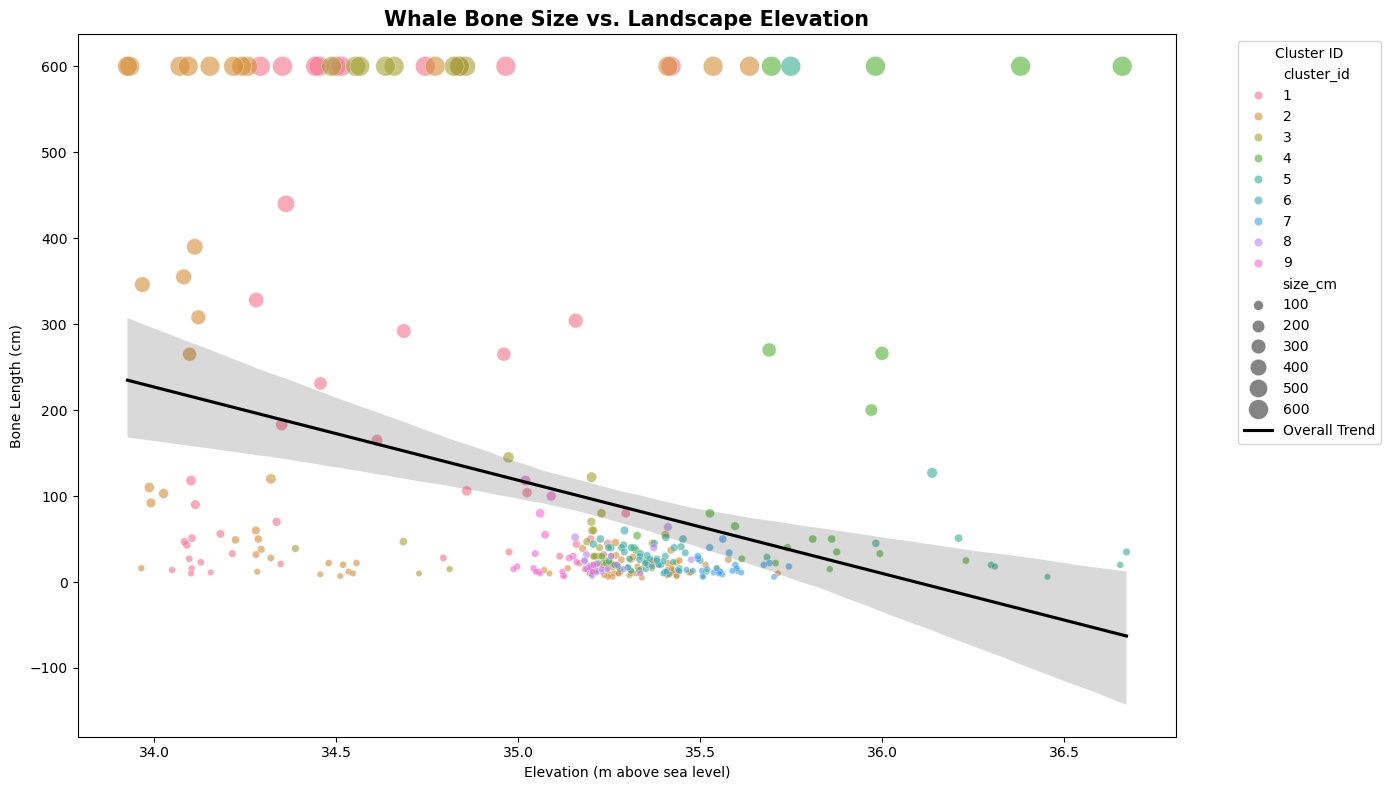


Pearson Correlation (Elevation vs. Size): -0.309

--- CLUSTER LOGISTICS SUMMARY ---
           size_cm        elevation
              mean count       mean
cluster_id                         
1           205.35    46  34.610001
2           101.21   108  35.000000
3           219.62    26  34.950001
4           150.96    25  35.750000
5            45.10    39  35.549999
6            27.95    20  35.380001
7            17.41    27  35.560001
8            22.81    21  35.250000
9            31.15    20  35.099998


In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# =================================================================
# 1. SETTINGS (Updated Paths)
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Clusters_Final.gpkg')
length_col = 'size_cm'

# =================================================================
# 2. LOAD & PREPARE DATA
# =================================================================
whales = gpd.read_file(points_gpkg, layer='Points')
# Filter: Nur geclusterte Punkte mit gültigem Messwert
whales_clean = whales[(whales['cluster_id'] != -1)].copy()
whales_clean[length_col] = pd.to_numeric(whales_clean[length_col], errors='coerce')
whales_clean = whales_clean.dropna(subset=[length_col])

# =================================================================
# 3. EXTRACT ELEVATION (Subprocess call to avoid DLL conflicts on Windows)
# =================================================================
import subprocess
import sys

base_path_esc = base_path.replace('\\', '\\\\')

subprocess.run([sys.executable, "-c", f"""
import geopandas as gpd
import rasterio
import numpy as np
import os
import pandas as pd

base_path = r"{base_path_esc}"
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Clusters_Final.gpkg')
length_col = 'size_cm'

whales = gpd.read_file(points_gpkg, layer='Points')
whales_clean = whales[(whales['cluster_id'] != -1)].copy()
whales_clean[length_col] = pd.to_numeric(whales_clean[length_col], errors='coerce')
whales_clean = whales_clean.dropna(subset=[length_col])

with rasterio.open(dem_path) as src:
    if whales_clean.crs != src.crs:
        whales_clean = whales_clean.to_crs(src.crs)
    coord_list = np.column_stack((whales_clean.geometry.x, whales_clean.geometry.y))
    whales_clean['elevation'] = [val[0] for val in src.sample(coord_list)]

whales_clean.to_pickle('temp_elevation_clean.pkl')
"""])

whales_clean = pd.read_pickle('temp_elevation_clean.pkl')
if os.path.exists('temp_elevation_clean.pkl'):
    os.remove('temp_elevation_clean.pkl')

# =================================================================
# 4. VISUALIZATION: SIZE VS TOPOGRAPHY
# =================================================================
num_clusters = len(whales_clean['cluster_id'].unique())
cluster_palette = sns.color_palette("husl", num_clusters)

fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot A: Scatterplot Size vs. Elevation (The "Logistics" Plot)
sns.scatterplot(
    data=whales_clean, 
    x='elevation', 
    y=length_col, 
    hue='cluster_id', 
    palette=cluster_palette,
    size=length_col, 
    sizes=(20, 200),
    alpha=0.6,
    ax=ax1
)
sns.regplot(data=whales_clean, x='elevation', y=length_col, scatter=False, color='black', ax=ax1, label='Overall Trend')

ax1.set_title('Whale Bone Size vs. Landscape Elevation', fontsize=15, fontweight='bold')
ax1.set_xlabel('Elevation (m above sea level)')
ax1.set_ylabel('Bone Length (cm)')
ax1.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'Whale_Size_Topography_Correlation.png'), dpi=300, bbox_inches='tight')
plt.show()

# =================================================================
# 5. SUMMARY STATISTICS
# =================================================================
corr = whales_clean['elevation'].corr(whales_clean[length_col])
print(f"\nPearson Correlation (Elevation vs. Size): {corr:.3f}")

summary = whales_clean.groupby('cluster_id').agg({
    length_col: ['mean', 'count'],
    'elevation': 'mean'
}).round(2)
print("\n--- CLUSTER LOGISTICS SUMMARY ---")
print(summary)


## Section 3: Surface Stability & Slope Gradient Analysis

### Purpose
Calculates the terrain slope (in degrees) from the DEM to assess the stability and flatness of the working surfaces where each whale bone cluster was deposited.

### Workflow & Functions
1. **Slope Calculation**: Loads the DEM data as a numpy array, masks invalid NoData values, and uses `np.gradient` to calculate the changes in elevation in both X and Y directions. The slope in degrees is calculated using: 
   $$\theta = \arctan(\sqrt{dx^2 + dy^2}) \cdot \frac{180}{\pi}$$
2. **Point Sampling**: Converts point coordinates to raster row/column indices using `rasterio.transform.rowcol` and samples the calculated slope values.
3. **Visualization (Boxplot)**: Displays the slope angles for each cluster. A dashed red line at $5^\circ$ indicates the theoretical stability threshold (slope $< 5^\circ$ indicates a flat, stable surface suitable for processing/work areas).
4. **Slope Statistics**: Groups by cluster to print mean, max, and standard deviation of slope gradients.

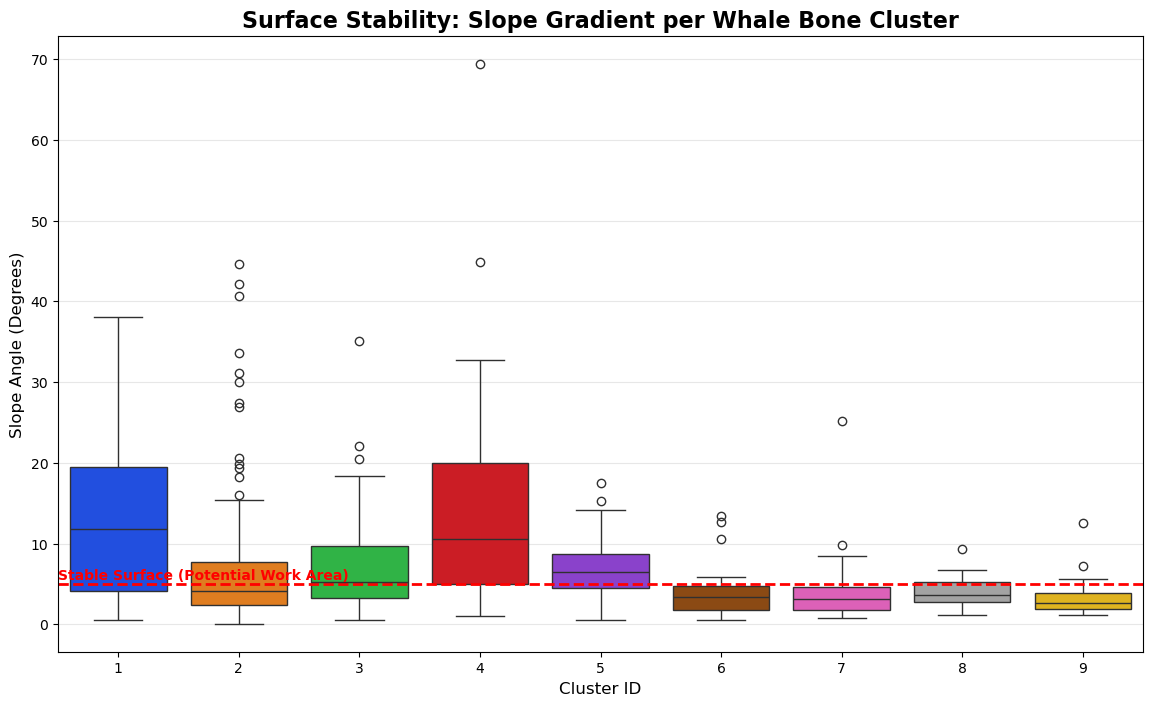

--- MEAN SLOPE AND STABILITY ---
             mean        max    std
cluster_id                         
1           13.16  38.049999  10.13
2            7.51  44.580002   9.02
3            8.02  35.119999   8.12
4           15.68  69.440002  15.44
5            6.94  17.469999   3.75
6            4.22  13.400000   3.76
7            4.40  25.139999   4.74
8            4.08   9.380000   2.01
9            3.58  12.520000   2.64


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# =================================================================
# 1. SETTINGS
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Clusters_Final.gpkg')

# =================================================================
# 2 & 3. SLOPE RASTER & SAMPLING (Subprocess call to avoid DLL conflicts on Windows)
# =================================================================
import subprocess
import sys

base_path_esc = base_path.replace('\\', '\\\\')

subprocess.run([sys.executable, "-c", f"""
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
import numpy as np
import os

base_path = r"{base_path_esc}"
dem_path = os.path.join(base_path, 'Gashamda_DEM_250822.tif') 
points_gpkg = os.path.join(base_path, 'Gashamna_Whale_Clusters_Final.gpkg')

with rasterio.open(dem_path) as dataset:
    dem_data = dataset.read(1)
    nodata = dataset.nodata
    if nodata is not None:
        dem_data = np.where(dem_data == nodata, np.nan, dem_data)
    res_x, res_y = dataset.res
    transform = dataset.transform
    dy, dx = np.gradient(dem_data, res_y, res_x)
    slope_array = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi)

whales = gpd.read_file(points_gpkg, layer='Points')
whales_clustered = whales[whales['cluster_id'] != -1].copy()

with rasterio.open(dem_path) as dataset:
    if whales_clustered.crs != dataset.crs:
        whales_clustered = whales_clustered.to_crs(dataset.crs)
    transform = dataset.transform

rows, cols = rowcol(transform, whales_clustered.geometry.x, whales_clustered.geometry.y)
rows = np.clip(rows, 0, slope_array.shape[0] - 1)
cols = np.clip(cols, 0, slope_array.shape[1] - 1)
whales_clustered['slope_deg'] = slope_array[rows, cols]

whales_clustered.to_pickle('temp_slope.pkl')
"""])

whales_clustered = pd.read_pickle('temp_slope.pkl')
if os.path.exists('temp_slope.pkl'):
    os.remove('temp_slope.pkl')

# =================================================================
# 4. VISUALIZATION
# =================================================================
num_clusters = len(whales_clustered['cluster_id'].unique())
cluster_palette = sns.color_palette("bright", num_clusters)

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=whales_clustered, 
    x='cluster_id', 
    y='slope_deg', 
    hue='cluster_id', 
    palette=cluster_palette, 
    legend=False
)

plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Stability Threshold (5°)')
plt.text(-0.5, 5.5, 'Stable Surface (Potential Work Area)', color='red', fontweight='bold')

plt.title('Surface Stability: Slope Gradient per Whale Bone Cluster', fontsize=16, fontweight='bold')
plt.ylabel('Slope Angle (Degrees)', fontsize=12)
plt.xlabel('Cluster ID', fontsize=12)
plt.grid(axis='y', alpha=0.3)

output_img = os.path.join(base_path, 'Whale_Slope_Analysis_Fixed.png')
plt.savefig(output_img, dpi=300, bbox_inches='tight')
plt.show()

print("--- MEAN SLOPE AND STABILITY ---")
stats = whales_clustered.groupby('cluster_id')['slope_deg'].agg(['mean', 'max', 'std']).round(2)
print(stats)
